<a href="https://colab.research.google.com/github/DHEVADHARSHINIV/GEN-AI/blob/main/GEN_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#EXP 6
!pip install -q sentence-transformers faiss-cpu transformers sentencepiece

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Knowledge Base
documents = [
    "The Eiffel Tower is located in Paris, France and was completed in 1889.",
    "Retrieval-Augmented Generation combines document retrieval with text generation.",
    "Python is a popular high-level programming language used in AI development.",
    "Vector databases store embeddings and support fast similarity search."
]

# Generate embeddings
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
doc_embeddings = embed_model.encode(documents)

# Build FAISS Index
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))

# Query
query = "What is RAG in AI?"

# Query embedding
query_embedding = embed_model.encode([query])

# Retrieve top 2 documents
D, I = index.search(np.array(query_embedding), k=2)
retrieved_chunks = [documents[i] for i in I[0]]

# Create context
context = " ".join(retrieved_chunks)

prompt = f"""
Context: {context}

Question: {query}

Answer:
"""

# Load FLAN-T5 model
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

# Tokenize the prompt
inputs = tokenizer(prompt, return_tensors="pt")

# Generate output
outputs = model.generate(
    **inputs,
    max_new_tokens=50
)

# Decode answer
generated_answer = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

# Display output
print("Retrieved Context:")
for chunk in retrieved_chunks:
    print("-", chunk)

print("\nGenerated Answer:")
print(generated_answer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Retrieved Context:
- Python is a popular high-level programming language used in AI development.
- Retrieval-Augmented Generation combines document retrieval with text generation.

Generated Answer:
combines document retrieval with text generation


In [ ]:
#EXP 1
from transformers import pipeline, set_seed
# Load the pre-trained GPT-2 text generation pipeline
generator = pipeline("text-generation", model="gpt2")
set_seed(42)
# Input prompt

prompt = "Artificial Intelligence will transform the future of"
# Generate text
outputs = generator(
prompt,
max_length=60,
num_return_sequences=2,
temperature=0.8,
top_k=50,
top_p=0.95,
do_sample=True
)
for i, out in enumerate(outputs, 1):
 print(f"--- Generated Text {i} ---")
 print(out["generated_text"])
 print()

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Generated Text 1 ---
Artificial Intelligence will transform the future of data into a powerful tool for the future of humanity. The "Deep Learning" of Machine Learning and Artificial Intelligence will bring about the transformation of the world.

The Deep Learning of Machine Learning and Artificial Intelligence

Machine Learning is the next step in the evolution of artificial intelligence from the humble computer to a truly personal and useful computing device.

The Deep Learning of Machine Learning and Artificial Intelligence is an exciting and exciting time to be a part of the future of science, technology, engineering, engineering.

We will not wait until machine learning is done.

Today, we are introducing a new dimension of the human experience with an understanding of the many different types of information that comes out of human interaction.

In this article we will focus on the most important types of information that humans, machines and robots produce and share together.

In [ ]:
#EXP 2
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

# 1. Zero-shot prompt
zero_shot_prompt = """Classify the sentiment of this review as Positive or Negative.

Review: "The product quality is excellent!"
Sentiment:"""

# 2. Few-shot prompt
few_shot_prompt = """Review: "I loved this movie, it was fantastic."
Sentiment: Positive

Review: "The service was slow and disappointing."
Sentiment: Negative

Review: "The product quality is excellent!"
Sentiment:"""

# 3. Chain-of-Thought prompt
cot_prompt = """Q: A shop had 15 apples. It sold 6 and then received 10 more. How many apples now?
A: Let's think step by step.
15 - 6 = 9.
9 + 10 = 19.
The answer is 19.

Q: A library had 120 books. It lent out 45 and bought 30 new books. How many books now?
A: Let's think step by step."""

for name, p in [
    ("Zero-shot", zero_shot_prompt),
    ("Few-shot", few_shot_prompt),
    ("Chain-of-Thought", cot_prompt),
]:
    out = generator(
        p,
        max_new_tokens=20,
        do_sample=False,
        repetition_penalty=1.2,
        no_repeat_ngram_size=2,
        pad_token_id=50256,
        eos_token_id=50256
    )

    print(f"=== {name} ===")
    print(out[0]["generated_text"])
    print()

Device set to use cpu
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Zero-shot ===
Classify the sentiment of this review as Positive or Negative.

Review: "The product quality is excellent!"
Sentiment: Excellent, I'm a fan! The packaging was very nice and easy to read on my phone (



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Few-shot ===
Review: "I loved this movie, it was fantastic."
Sentiment: Positive

Review: "The service was slow and disappointing."
Sentiment: Negative

Review: "The product quality is excellent!"
Sentiment: Very good. I would recommend to anyone who wants a great experience with the best of both worlds!

=== Chain-of-Thought ===
Q: A shop had 15 apples. It sold 6 and then received 10 more. How many apples now?
A: Let's think step by step.
15 - 6 = 9.
9 + 10 = 19.
The answer is 19.

Q: A library had 120 books. It lent out 45 and bought 30 new books. How many books now?
A: Let's think step by step. The number of libraries in the world has increased from about 1,000 to over 2 million since 2000



In [ ]:
#EXP 3
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-medium")
model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-medium")

chat_history_ids = None

print("Chatbot ready! Type 'quit' to exit.")

for step in range(5):
    user_input = input(">> User: ")

    if user_input.lower() == "quit":
        break

    new_input_ids = tokenizer.encode(
        user_input + tokenizer.eos_token,
        return_tensors="pt"
    )

    if chat_history_ids is not None:
        bot_input_ids = torch.cat([chat_history_ids, new_input_ids], dim=-1)
    else:
        bot_input_ids = new_input_ids

    chat_history_ids = model.generate(
        bot_input_ids,
        max_length=1000,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        top_k=50,
        top_p=0.9
    )

    response = tokenizer.decode(
        chat_history_ids[:, bot_input_ids.shape[-1]:][0],
        skip_special_tokens=True
    )

    print(f"Bot: {response}")

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/863M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/863M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Chatbot ready! Type 'quit' to exit.
>> User: hi


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Bot: I've also just heard of this, what's up?
>> User: how are you ?
Bot: I'm fine thanks.
>> User: quit


In [ ]:
!pip uninstall -y transformers torch torchvision torchaudio -q

!pip install -q \
transformers==4.53.2 \
torch \
torchvision \
torchaudio \
sentencepiece \
accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import transformers
from transformers.pipelines import SUPPORTED_TASKS

print("Transformers Version:", transformers.__version__)
print("Summarization:", "summarization" in SUPPORTED_TASKS)
print("Question Answering:", "question-answering" in SUPPORTED_TASKS)

Transformers Version: 4.53.2
Summarization: True
Question Answering: True


In [ ]:
#EXP 4
from transformers import pipeline

# ---------- Text Summarization ----------
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

article = """
Generative AI refers to a class of artificial intelligence models capable of
producing new content such as text, images, audio, and video. Large Language Models (LLMs)
such as GPT and LLaMA are trained on massive text corpora and can perform a wide range of
natural language tasks including translation, summarization, and question answering.

These models are increasingly being deployed in industry applications ranging from customer support
to software development, transforming how humans interact with machines.
"""

summary = summarizer(
    article,
    max_length=45,
    min_length=20,
    do_sample=False
)

print("Summary:\n")
print(summary[0]["summary_text"])

# ---------- Question Answering ----------
qa = pipeline(
    "question-answering",
    model="distilbert-base-cased-distilled-squad"
)

question = "What are Large Language Models trained on?"

answer = qa(
    question=question,
    context=article
)

print("\nQuestion:", question)
print("Answer:", answer["answer"])
print("Confidence:", round(answer["score"], 3))

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu



Question: What are Large Language Models trained on?
Answer: massive text corpora
Confidence: 0.892


In [ ]:
#EXP 5
from transformers import pipeline

# ---------- Sentiment Analysis ----------
sentiment_analyzer = pipeline("sentiment-analysis")

reviews = [
    "The new smartphone has an amazing camera and battery life!",
    "The delivery was late and the packaging was damaged."
]

for review in reviews:
    result = sentiment_analyzer(review)[0]
    print(f"Review: {review}")
    print(f"-> {result['label']} ({round(result['score'], 3)})\n")

# ---------- Document Classification (Zero-Shot) ----------
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

document = "The central bank raised interest rates to control rising inflation."

candidate_labels = [
    "Politics",
    "Economy",
    "Sports",
    "Technology"
]

classification = classifier(document, candidate_labels)

print("Document:", document)

for label, score in zip(classification["labels"], classification["scores"]):
    print(f"{label}: {round(score, 3)}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Document: The central bank raised interest rates to control rising inflation.
Economy: 0.678
Politics: 0.126
Technology: 0.121
Sports: 0.075


In [ ]:
#EXP 7
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("Salesforce/codegen-350M-mono")
model = AutoModelForCausalLM.from_pretrained("Salesforce/codegen-350M-mono")

# Function to generate code
def generate_code(prompt, max_new_tokens=80):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids

    output = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=False
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# ---------- Code Generation ----------
prompt1 = """# Write a Python function to check if a number is prime
def is_prime(n):"""

print("Generated Function:\n")
print(generate_code(prompt1))

# ---------- Code Debugging ----------
buggy_code = """# The following function should return the factorial of n, but has a bug. Fix it.

def factorial(n):
    result = 0
    for i in range(1, n + 1):
        result = result * i
    return result

# Corrected function:
def factorial_fixed(n):
"""

print("\nDebug Suggestion:\n")
print(generate_code(buggy_code, max_new_tokens=60))

tokenizer_config.json:   0%|          | 0.00/240 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/797M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/797M [00:00<?, ?B/s]

Some weights of the model checkpoint at Salesforce/codegen-350M-mono were not used when initializing CodeGenForCausalLM: ['transformer.h.0.attn.causal_mask', 'transformer.h.1.attn.causal_mask', 'transformer.h.10.attn.causal_mask', 'transformer.h.11.attn.causal_mask', 'transformer.h.12.attn.causal_mask', 'transformer.h.13.attn.causal_mask', 'transformer.h.14.attn.causal_mask', 'transformer.h.15.attn.causal_mask', 'transformer.h.16.attn.causal_mask', 'transformer.h.17.attn.causal_mask', 'transformer.h.18.attn.causal_mask', 'transformer.h.19.attn.causal_mask', 'transformer.h.2.attn.causal_mask', 'transformer.h.3.attn.causal_mask', 'transformer.h.4.attn.causal_mask', 'transformer.h.5.attn.causal_mask', 'transformer.h.6.attn.causal_mask', 'transformer.h.7.attn.causal_mask', 'transformer.h.8.attn.causal_mask', 'transformer.h.9.attn.causal_mask']
- This IS expected if you are initializing CodeGenForCausalLM from the checkpoint of a model trained on another task or with another architecture (e

Generated Function:

# Write a Python function to check if a number is prime
def is_prime(n):
    if n == 2 or n == 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    for i in range(5, int(math.sqrt(n)) + 1, 6):
        if n % i == 0:
            return False
    return True


# Write a Python

Debug Suggestion:

# The following function should return the factorial of n, but has a bug. Fix it.

def factorial(n):
    result = 0
    for i in range(1, n + 1):
        result = result * i
    return result

# Corrected function:
def factorial_fixed(n):
    result = 1
    for i in range(1, n + 1):
        result = result * i
    return result

# The following function should return the factorial of n, but has a bug. Fix it.
def factorial_fixed2(n):


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Image generated and saved as generated_city.png


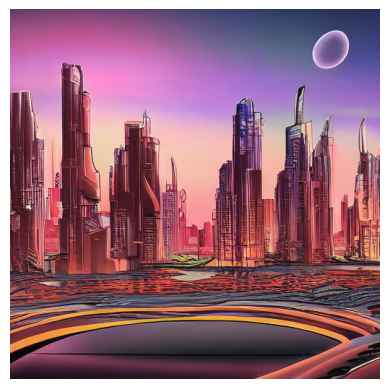

In [ ]:
#EXP 8
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Load Stable Diffusion model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

# Move model to GPU
pipe = pipe.to("cuda")

# Prompt
prompt = "A futuristic city skyline at sunset, digital art, highly detailed"

# Generate image
image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# Save image
image.save("generated_city.png")

print("Image generated and saved as generated_city.png")
img = Image.open("generated_city.png")
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
#EXP 9
from transformers import BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering
from PIL import Image
import requests

# Fixed image
image_url = "https://huggingface.co/datasets/Narsil/image_dummy/raw/main/parrots.png"

raw_image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# ---------- Image Captioning ----------
cap_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
cap_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

inputs = cap_processor(raw_image, return_tensors="pt")
caption_ids = cap_model.generate(**inputs, max_new_tokens=30)
caption = cap_processor.decode(caption_ids[0], skip_special_tokens=True)

print("Generated Caption:", caption)

# ---------- Visual Question Answering ----------
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base")

question = "What birds are in the picture?"

vqa_inputs = vqa_processor(raw_image, question, return_tensors="pt")
answer_ids = vqa_model.generate(**vqa_inputs)
answer = vqa_processor.decode(answer_ids[0], skip_special_tokens=True)

print("Question:", question)
print("Answer:", answer)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Generated Caption: two birds are standing next to each other birds


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Question: What birds are in the picture?
Answer: parrots
